In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

from src.utils.config import load_config
from src.models.model import ReconstructionModel

In [2]:
config = load_config("../configs/config.yaml")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ReconstructionModel(config).to(device)
model.load_state_dict(torch.load("../outputs/model_best.pth", map_location=device))
model.eval()

c:\Shivansh\aiml\shapenet\venv_shapenet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Shivansh\aiml\shapenet\venv_shapenet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ReconstructionModel(
  (encoder): Encoder(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(

In [3]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [4]:
# def show_voxel(voxel, threshold=0.4):
#     voxel = voxel.squeeze()  # [32,32,32]

#     voxel = np.rot90(voxel, k=1, axes=(1, 2))  # (y, z)
#     # voxel = np.rot90(voxel, k=1, axes=(0, 2))  # (x, z)

#     voxel = (voxel > threshold)

#     fig = plt.figure(figsize=(6, 6))
#     ax = fig.add_subplot(111, projection='3d')

#     ax.voxels(voxel, edgecolor='k')

#     plt.show()

def show_voxel(voxel, ax, threshold=0.4, binary=True, title=""):
    voxel = voxel.squeeze()
    voxel = np.rot90(voxel, k=1, axes=(1, 2))

    if binary:
        voxel = (voxel > threshold)

    ax.voxels(voxel, edgecolor='k')
    ax.set_title(title)
    ax.set_axis_off()

def compute_iou(pred, target, threshold=0.4):
    pred = (pred > threshold).astype(np.float32)

    intersection = (pred * target).sum()
    union = ((pred + target) > 0).sum()

    return intersection / (union + 1e-6)


Model ID: 4a12589099b05c51e13b3410f3683610
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\4a12589099b05c51e13b3410f3683610\rendering\19.png
Loaded image and GT voxel
Prediction stats:
Min: 3.4579767e-05 Max: 0.99826825


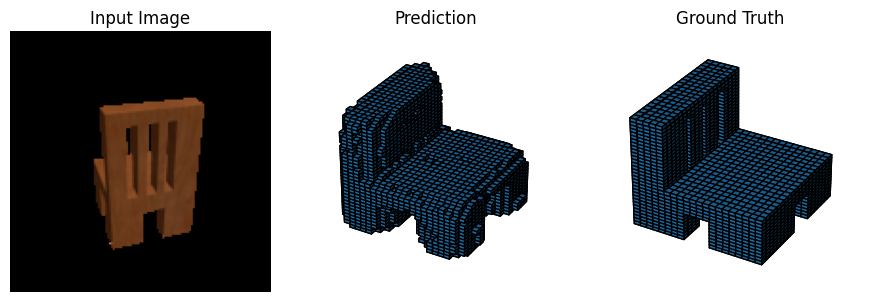

Threshold 0.3: IoU = 0.6076
Threshold 0.4: IoU = 0.6277
Threshold 0.5: IoU = 0.6582

Model ID: 3b57aac4b7f4b9f52d19175e7d19b7cb
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\3b57aac4b7f4b9f52d19175e7d19b7cb\rendering\16.png
Loaded image and GT voxel
Prediction stats:
Min: 2.5184292e-05 Max: 0.99941087


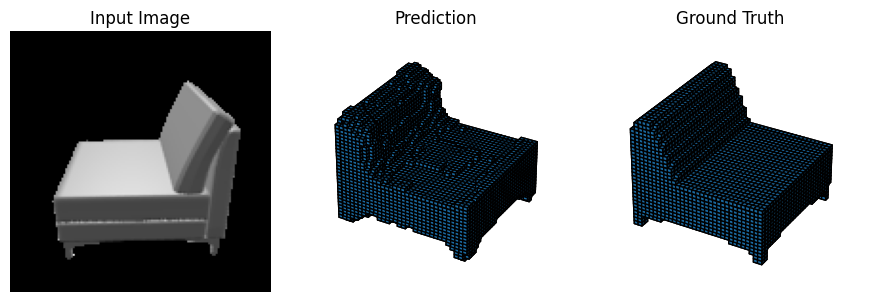

Threshold 0.3: IoU = 0.7926
Threshold 0.4: IoU = 0.7982
Threshold 0.5: IoU = 0.7970

Model ID: c1c0b3d35cdef5e2f51fa0238791f5dc
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\c1c0b3d35cdef5e2f51fa0238791f5dc\rendering\19.png
Loaded image and GT voxel
Prediction stats:
Min: 3.5520225e-05 Max: 0.9961604


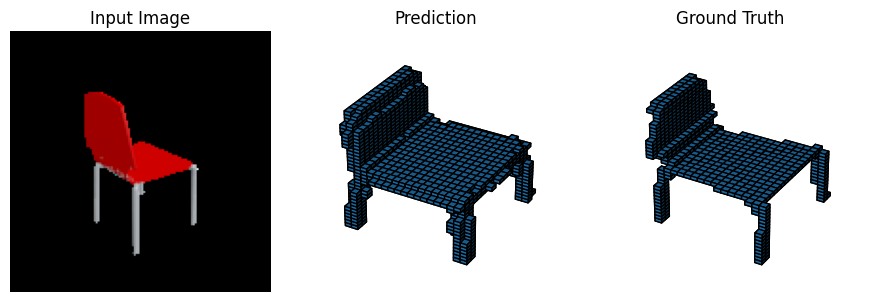

Threshold 0.3: IoU = 0.3568
Threshold 0.4: IoU = 0.3808
Threshold 0.5: IoU = 0.4017

Model ID: 31f5725faebb53aba1fb86e891f97aa
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\31f5725faebb53aba1fb86e891f97aa\rendering\13.png
Loaded image and GT voxel
Prediction stats:
Min: 6.64667e-05 Max: 0.9982821


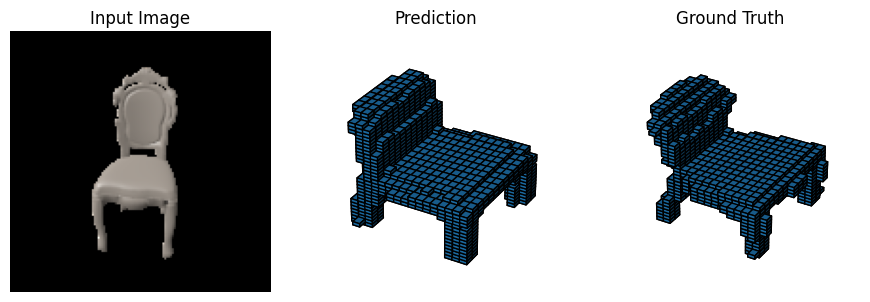

Threshold 0.3: IoU = 0.6265
Threshold 0.4: IoU = 0.6376
Threshold 0.5: IoU = 0.6536

Model ID: b7073426bf9332187c564a6b9ce2156f
Image: C:/Shivansh/aiml/shapenet/src/data/ShapeNetRendering/ShapeNetRendering\03001627\b7073426bf9332187c564a6b9ce2156f\rendering\15.png
Loaded image and GT voxel
Prediction stats:
Min: 5.1567804e-05 Max: 0.9873071


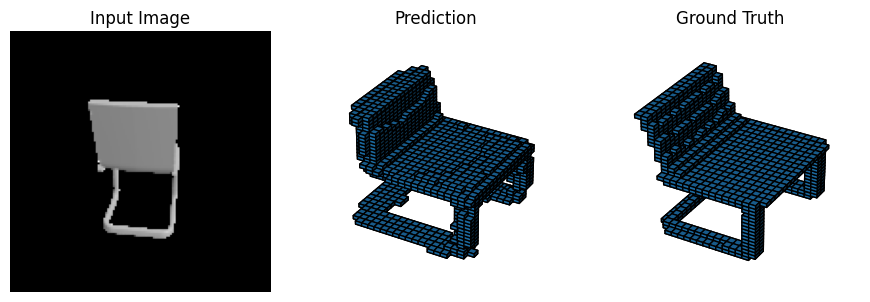

Threshold 0.3: IoU = 0.5059
Threshold 0.4: IoU = 0.5077
Threshold 0.5: IoU = 0.4855


In [7]:
config = load_config("../configs/config.yaml")

render_dir = os.path.join(config["paths"]["rendering_dir"], config["data"]["class_id"])
voxel_dir = os.path.join(config["paths"]["voxel_dir"], config["data"]["class_id"])

model_ids = os.listdir(render_dir)
random_models = random.sample(model_ids, min(5, len(model_ids)))

for model_id in random_models:
    image_folder = os.path.join(render_dir, model_id, "rendering")
    voxel_path = os.path.join(voxel_dir, model_id, "model.binvox")

    if not os.path.exists(image_folder) or not os.path.exists(voxel_path):
        continue

    images = [
        os.path.join(image_folder, f)
        for f in os.listdir(image_folder)
        if f.endswith(".png")
    ]

    if len(images) == 0:
        continue

    image_path = random.choice(images)

    print("\n==============================")
    print("Model ID:", model_id)
    print("Image:", image_path)

    # 🔥 Load image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    import numpy as np
    from src.utils import binvox_rw

    # 🔥 Load GT voxel
    with open(voxel_path, 'rb') as f:
        gt_voxel = binvox_rw.read_as_3d_array(f).data.astype(np.float32)

    gt_voxel = np.expand_dims(gt_voxel, axis=(0,1))  # fix shape

    print("Loaded image and GT voxel")

    # 🔥 Prediction
    with torch.no_grad():
        logits = model(image_tensor)
        pred_voxel = torch.sigmoid(logits).cpu().numpy()

    print("Prediction stats:")
    print("Min:", pred_voxel.min(), "Max:", pred_voxel.max())

    # 🔥 Visualization
    fig = plt.figure(figsize=(9, 3))

    # 🖼️ Input Image
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(image)
    ax1.set_title("Input Image")
    ax1.axis("off")

    # 🔵 Predicted Voxel
    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    show_voxel(pred_voxel[0], ax2, threshold=0.4, title="Prediction")

    # 🟢 Ground Truth
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    show_voxel(gt_voxel[0], ax3, threshold=0.5, title="Ground Truth")

    plt.tight_layout()
    plt.show()

    # 🔥 IoU at multiple thresholds
    for t in [0.3, 0.4, 0.5]:
        iou = compute_iou(pred_voxel[0], gt_voxel[0], threshold=t)
        print(f"Threshold {t}: IoU = {iou:.4f}")